# Refresh Opportunity Scoring

## Capstone Research Question

Which content pages should be prioritized for review or refresh based on
observed search-performance signals?

### Goal

The goal of this project is to build a repeatable content-opportunity
scoring system using the FlyRank ML Internship warehouse dataset.

The output will rank content opportunities for review using public-safe,
evidence-based signals. The analysis is intended for decision support,
not as proof of causal ranking effects.

In [11]:
!pip install -q duckdb pandas numpy scikit-learn matplotlib pyarrow

In [15]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Setup complete.")

Setup complete.


In [9]:
import duckdb

con = duckdb.connect()

HF_TOKEN = "hf_YOUR_READ_TOKEN_HERE"

con.execute("DROP SECRET IF EXISTS hf_secret")

con.execute(f"""
CREATE SECRET hf_secret (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
);
""")

print("Hugging Face authentication configured.")

Hugging Face authentication configured.


### Method 1: Using `os.environ` (Python only for current process)

In [3]:
import os

# Set the environment variable
os.environ['MY_ENV_VAR'] = 'my_value'

# Verify it's set
print(os.environ.get('MY_ENV_VAR'))

my_value


In [6]:
# Check available warehouse parquet files
files = con.execute("""
SELECT file
FROM glob('hf://datasets/FlyRank/internship-warehouse/**/*.parquet')
LIMIT 50
""").df()

display(files)

,file
0,hf://datasets/FlyRank/internship-warehouse/dim...
1,hf://datasets/FlyRank/internship-warehouse/dim...
2,hf://datasets/FlyRank/internship-warehouse/fac...
3,hf://datasets/FlyRank/internship-warehouse/fac...
4,hf://datasets/FlyRank/internship-warehouse/fac...
5,hf://datasets/FlyRank/internship-warehouse/fac...
6,hf://datasets/FlyRank/internship-warehouse/fac...
7,hf://datasets/FlyRank/internship-warehouse/fac...
8,hf://datasets/FlyRank/internship-warehouse/fac...
9,hf://datasets/FlyRank/internship-warehouse/fac...


In [7]:
print("Number of files shown:", len(files))

for f in files["file"]:
    print(f)

Number of files shown: 22
hf://datasets/FlyRank/internship-warehouse/dim_clients.parquet
hf://datasets/FlyRank/internship-warehouse/dim_content.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-01/data_0.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-02/data_0.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-03/data_0.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-04/data_0.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-05/data_0.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-06/data_0.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-07/data_0.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-08/data_0.parquet
hf://datasets/FlyRank/in

In [12]:
!pip install -q -U huggingface_hub duckdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.9/842.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 68.2 MB/s eta 0:00:00


In [14]:
from huggingface_hub import login

login()

In [15]:
import duckdb

con = duckdb.connect()

con.execute("""
CREATE OR REPLACE SECRET hf_token (
    TYPE huggingface,
    PROVIDER credential_chain
);
""")

print("DuckDB authentication ready.")

DuckDB authentication ready.


In [21]:
from huggingface_hub import login

login()

In [22]:
import duckdb

con = duckdb.connect()

con.execute("""
CREATE OR REPLACE SECRET hf_token (
    TYPE huggingface,
    PROVIDER credential_chain
);
""")

print("Authentication ready!")

Authentication ready!


In [24]:
!pip install -q -U huggingface_hub

In [26]:
from huggingface_hub import login, whoami

login()

info = whoami()
print("Logged in as:", info["name"])

Logged in as: forhadmia231


In [27]:
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="dim_content.parquet",
    repo_type="dataset"
)

print("SUCCESS!")
print(file_path)

dim_content.parquet: reconstructing file:   0%|          |  0.00B / 19.6MB            

dim_content.parquet: downloading bytes:           |  0.00B            

SUCCESS!
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/dim_content.parquet


In [28]:
import duckdb

con = duckdb.connect()

dim_content_sample = con.execute(f"""
SELECT *
FROM read_parquet('{file_path}')
LIMIT 5
""").df()

print("DIM CONTENT COLUMNS:")
print(dim_content_sample.columns.tolist())

display(dim_content_sample)

DIM CONTENT COLUMNS:
['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'url_hash_id', 'keyword_char_count', 'keyword_token_count', 'url_char_count', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'cpc', 'main_intent', 'backlinks', 'category_count', 'keyword_created_date', 'provider_used', 'model_used', 'char_count', 'word_count', 'last_optimized_date', 'optimization_eligible_date', 'is_published', 'is_deleted']


,client_hash_id,content_hash_id,keyword_hash_id,url_hash_id,keyword_char_count,keyword_token_count,url_char_count,content_created_date,content_updated_date,content_type,...,category_count,keyword_created_date,provider_used,model_used,char_count,word_count,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,keyword_e754999ab88dd9f2,url_d6091f18cf628794,22,4,108,2026-05-30,2026-07-01,keyword article,...,3,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15682,2555,NaT,NaT,True,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,keyword_4329d7aede8e208b,url_3a66d2f2e36823ca,31,6,95,2026-06-12,2026-07-01,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15438,2430,NaT,NaT,True,False
2,client_04660893ae39614a,content_01410f2556c327ac,keyword_9b08047d3d2a0406,url_809eda7a7e20b3b2,22,5,82,2026-05-09,2026-07-01,keyword article,...,4,2026-05-06,gemini-generate-content,gemini-3-flash-preview,16576,2645,NaT,NaT,True,False
3,client_04660893ae39614a,content_019f27f634053ca7,keyword_e7cec7ab1804c1c2,url_5fb42bafc4399861,14,3,92,2026-06-15,2026-06-15,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15457,2522,NaT,NaT,True,False
4,client_04660893ae39614a,content_01efa71faea45dcc,keyword_56b0062a1d8b7524,url_ece0abc3e5fb75f9,24,6,98,2026-05-21,2026-06-01,keyword article,...,4,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15776,2552,NaT,NaT,True,False


In [29]:
from huggingface_hub import hf_hub_download

daily_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance_sample.parquet",
    repo_type="dataset"
)

print("Daily sample downloaded successfully!")
print(daily_path)

fact_content_daily_performance_sample.pa(…): reconstructing file:   0%|          |  0.00B /  145MB            

fact_content_daily_performance_sample.pa(…): downloading bytes:           |  0.00B            

Daily sample downloaded successfully!
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance_sample.parquet


In [30]:
daily_sample = con.execute(f"""
SELECT *
FROM read_parquet('{daily_path}')
LIMIT 5
""").df()

print("DAILY PERFORMANCE COLUMNS:")
print(daily_sample.columns.tolist())

display(daily_sample)

DAILY PERFORMANCE COLUMNS:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-06-01,client_3ffa76342f366962,content_1a6296faee432dae,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
1,2026-06-01,client_3ffa76342f366962,content_73f21e612565035a,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
2,2026-06-01,client_3ffa76342f366962,content_5a5be514ff559598,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
3,2026-06-01,client_3ffa76342f366962,content_05b377d0c8a5cfd8,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
4,2026-06-01,client_3ffa76342f366962,content_dc34c661d63e55a9,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06


In [31]:
summary = con.execute(f"""
SELECT
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date,
    COUNT(*) AS rows,
    COUNT(DISTINCT client_hash_id) AS clients,
    COUNT(DISTINCT content_hash_id) AS contents,

    SUM(gsc_impressions) AS impressions,
    SUM(gsc_clicks) AS clicks,
    SUM(ga4_pageviews) AS pageviews,
    SUM(ga4_sessions) AS sessions

FROM read_parquet('{daily_path}')
""").df()

display(summary)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_date,max_date,rows,clients,contents,impressions,clicks,pageviews,sessions
0,2026-06-01,2026-06-30,11694072,65,409205,216194872.0,1209117.0,4861097.0,2759763.0


In [32]:
availability = con.execute(f"""
SELECT
    COUNT(*) AS rows,

    SUM(CASE WHEN gsc_data_available THEN 1 ELSE 0 END) AS gsc_available_rows,
    SUM(CASE WHEN ga4_data_available THEN 1 ELSE 0 END) AS ga4_available_rows,

    SUM(CASE WHEN gsc_impressions > 0 THEN 1 ELSE 0 END) AS rows_with_impressions,
    SUM(CASE WHEN gsc_clicks > 0 THEN 1 ELSE 0 END) AS rows_with_clicks,
    SUM(CASE WHEN ga4_sessions > 0 THEN 1 ELSE 0 END) AS rows_with_sessions

FROM read_parquet('{daily_path}')
""").df()

display(availability)

,rows,gsc_available_rows,ga4_available_rows,rows_with_impressions,rows_with_clicks,rows_with_sessions
0,11694072,3878937.0,644726.0,3878937.0,447367.0,629244.0


In [33]:
content_perf = con.execute(f"""
SELECT
    client_hash_id,
    content_hash_id,

    COUNT(DISTINCT report_date) AS observed_days,

    SUM(gsc_impressions) AS impressions,
    SUM(gsc_clicks) AS clicks,

    CASE
        WHEN SUM(gsc_impressions) > 0
        THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
        ELSE 0
    END AS ctr,

    CASE
        WHEN SUM(gsc_impressions) > 0
        THEN SUM(gsc_sum_position) * 1.0 / SUM(gsc_impressions)
        ELSE NULL
    END AS avg_position,

    SUM(ga4_pageviews) AS pageviews,
    SUM(ga4_sessions) AS sessions,
    SUM(ga4_users) AS users,
    SUM(ga4_engaged_sessions) AS engaged_sessions,

    CASE
        WHEN SUM(ga4_sessions) > 0
        THEN SUM(ga4_engaged_sessions) * 1.0 / SUM(ga4_sessions)
        ELSE NULL
    END AS engagement_rate

FROM read_parquet('{daily_path}')

GROUP BY
    client_hash_id,
    content_hash_id
""").df()

print("Content-level dataset shape:", content_perf.shape)

display(content_perf.head(10))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Content-level dataset shape: (409205, 12)


,client_hash_id,content_hash_id,observed_days,impressions,clicks,ctr,avg_position,pageviews,sessions,users,engaged_sessions,engagement_rate
0,client_f623b01661d4bfe4,content_575a1ed6e670a9a3,25,2.0,0.0,0.0,48.000000,0.0,0.0,0.0,0.0,NaN
1,client_f623b01661d4bfe4,content_22290552590d7529,25,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN
2,client_f623b01661d4bfe4,content_bc7ee2e19eb9ce58,25,6.0,0.0,0.0,20.333333,0.0,0.0,0.0,0.0,NaN
3,client_f623b01661d4bfe4,content_5a8d5e9988c5cab3,25,3.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,NaN
4,client_f623b01661d4bfe4,content_ef950fcfe31b8458,25,5.0,0.0,0.0,7.000000,0.0,0.0,0.0,0.0,NaN
5,client_f623b01661d4bfe4,content_0df98e2c7ac5fb12,25,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN
6,client_f623b01661d4bfe4,content_ecd391a302a57ca4,25,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN
7,client_f623b01661d4bfe4,content_32f2de922c37cc7c,25,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN
8,client_f623b01661d4bfe4,content_800478688d03a921,25,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN
9,client_f623b01661d4bfe4,content_62494c005b8aad06,25,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN


In [34]:
print("=== DATASET SUMMARY ===")
display(summary)

print("\n=== DATA AVAILABILITY ===")
display(availability)

=== DATASET SUMMARY ===


,min_date,max_date,rows,clients,contents,impressions,clicks,pageviews,sessions
0,2026-06-01,2026-06-30,11694072,65,409205,216194872.0,1209117.0,4861097.0,2759763.0



=== DATA AVAILABILITY ===


,rows,gsc_available_rows,ga4_available_rows,rows_with_impressions,rows_with_clicks,rows_with_sessions
0,11694072,3878937.0,644726.0,3878937.0,447367.0,629244.0


In [35]:
eligible = content_perf[
    (content_perf["impressions"] > 0) &
    (content_perf["avg_position"].notna())
].copy()

print("Total content:", len(content_perf))
print("Eligible content:", len(eligible))

print("\n=== PERFORMANCE DISTRIBUTION ===")

display(
    eligible[
        ["impressions", "clicks", "ctr", "avg_position"]
    ].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90]
    )
)

Total content: 409205
Eligible content: 208636

=== PERFORMANCE DISTRIBUTION ===


,impressions,clicks,ctr,avg_position
count,208636.000000,208636.000000,208636.000000,208636.000000
mean,1036.229951,5.795342,0.007041,22.445777
std,5128.574042,457.917380,0.033001,22.711473
min,1.000000,0.000000,0.000000,0.000000
25%,12.000000,0.000000,0.000000,6.769231
50%,91.000000,0.000000,0.000000,12.000000
75%,511.000000,2.000000,0.003984,31.666667
90%,1988.000000,8.000000,0.011050,62.945726
max,615012.000000,152170.000000,1.000000,579.000000


In [36]:
impression_threshold = eligible["impressions"].quantile(0.75)
ctr_threshold = eligible["ctr"].quantile(0.50)

print("75th percentile impressions:", impression_threshold)
print("Median CTR:", ctr_threshold)

eligible["refresh_opportunity"] = (
    (eligible["impressions"] >= impression_threshold) &
    (eligible["ctr"] <= ctr_threshold)
).astype(int)

print("\n=== LABEL DISTRIBUTION ===")
print(eligible["refresh_opportunity"].value_counts())

print("\nPercentage labelled opportunity:")
print(
    eligible["refresh_opportunity"].mean() * 100
)

75th percentile impressions: 511.0
Median CTR: 0.0

=== LABEL DISTRIBUTION ===
refresh_opportunity
0    203998
1      4638
Name: count, dtype: int64

Percentage labelled opportunity:
2.223010410475661


In [37]:
comparison = (
    eligible
    .groupby("refresh_opportunity")[
        ["impressions", "clicks", "ctr", "avg_position"]
    ]
    .median()
)

display(comparison)

,impressions,clicks,ctr,avg_position
refresh_opportunity,,,,
0,84.0,0.0,0.0,11.888889
1,753.0,0.0,0.0,15.461421


In [38]:
from huggingface_hub import hf_hub_download

may_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-05/data_0.parquet",
    repo_type="dataset"
)

print("May 2026 downloaded successfully!")

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  149MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

May 2026 downloaded successfully!


In [39]:
may_perf = con.execute(f"""
SELECT
    client_hash_id,
    content_hash_id,

    COUNT(DISTINCT report_date) AS past_days,

    SUM(gsc_impressions) AS past_impressions,
    SUM(gsc_clicks) AS past_clicks,

    CASE
        WHEN SUM(gsc_impressions) > 0
        THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
        ELSE 0
    END AS past_ctr,

    CASE
        WHEN SUM(gsc_impressions) > 0
        THEN SUM(gsc_sum_position) * 1.0 / SUM(gsc_impressions)
        ELSE NULL
    END AS past_avg_position,

    SUM(ga4_pageviews) AS past_pageviews,
    SUM(ga4_sessions) AS past_sessions,
    SUM(ga4_users) AS past_users,
    SUM(ga4_engaged_sessions) AS past_engaged_sessions

FROM read_parquet('{may_path}')

GROUP BY
    client_hash_id,
    content_hash_id
""").df()

print("May content:", may_perf.shape)
display(may_perf.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

May content: (389153, 11)


,client_hash_id,content_hash_id,past_days,past_impressions,past_clicks,past_ctr,past_avg_position,past_pageviews,past_sessions,past_users,past_engaged_sessions
0,client_62f4a7e64f5e0096,content_0352f87f81479781,31,83.0,0.0,0.0,25.915663,NaN,NaN,NaN,NaN
1,client_62f4a7e64f5e0096,content_ad1a735b6e2575f2,31,287.0,0.0,0.0,12.365854,NaN,NaN,NaN,NaN
2,client_62f4a7e64f5e0096,content_6317f3c163c3cfb3,31,23.0,0.0,0.0,55.000000,NaN,NaN,NaN,NaN
3,client_62f4a7e64f5e0096,content_a66fa4ffa9ba87b5,31,24.0,0.0,0.0,44.166667,NaN,NaN,NaN,NaN
4,client_62f4a7e64f5e0096,content_012c7080d0d284df,31,14.0,0.0,0.0,33.285714,NaN,NaN,NaN,NaN


In [40]:
june_perf = content_perf.rename(columns={
    "impressions": "future_impressions",
    "clicks": "future_clicks",
    "ctr": "future_ctr",
    "avg_position": "future_avg_position",
    "pageviews": "future_pageviews",
    "sessions": "future_sessions",
    "users": "future_users",
    "engaged_sessions": "future_engaged_sessions"
}).copy()

In [41]:
model_df = may_perf.merge(
    june_perf,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Matched May → June content:", model_df.shape)

Matched May → June content: (389032, 21)


In [42]:
future_eligible = model_df[
    (model_df["future_impressions"] > 0) &
    (model_df["future_avg_position"].notna())
].copy()

future_imp_threshold = future_eligible["future_impressions"].quantile(0.75)
future_ctr_threshold = future_eligible["future_ctr"].quantile(0.50)

future_eligible["future_refresh_opportunity"] = (
    (future_eligible["future_impressions"] >= future_imp_threshold) &
    (future_eligible["future_ctr"] <= future_ctr_threshold)
).astype(int)

print("Future impression threshold:", future_imp_threshold)
print("Future CTR threshold:", future_ctr_threshold)

print("\n=== FUTURE LABEL ===")
print(
    future_eligible["future_refresh_opportunity"].value_counts()
)

print("\nOpportunity percentage:")
print(
    future_eligible["future_refresh_opportunity"].mean() * 100
)

Future impression threshold: 526.0
Future CTR threshold: 0.0

=== FUTURE LABEL ===
future_refresh_opportunity
0    195420
1      4334
Name: count, dtype: int64

Opportunity percentage:
2.169668692491765


In [44]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ---------------------------------
# 1. Leakage-safe May features
# ---------------------------------

features = [
    "past_days",
    "past_impressions",
    "past_clicks",
    "past_ctr",
    "past_avg_position",
    "past_pageviews",
    "past_sessions",
    "past_users",
    "past_engaged_sessions"
]

data = future_eligible[
    ["client_hash_id", "content_hash_id"] +
    features +
    ["future_refresh_opportunity"]
].copy()

# Handle missing values using training-safe simple constants
data[features] = data[features].replace([np.inf, -np.inf], np.nan)
data[features] = data[features].fillna(0)

X = data[features]
y = data["future_refresh_opportunity"]
groups = data["client_hash_id"]

print("Dataset shape:", data.shape)
print("\nTarget distribution:")
print(y.value_counts())

Dataset shape: (199754, 12)

Target distribution:
future_refresh_opportunity
0    195420
1      4334
Name: count, dtype: int64


In [45]:
# ---------------------------------
# 2. Grouped split by client
# ---------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))

print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))

print(
    "Client overlap:",
    len(train_clients.intersection(test_clients))
)

Train rows: 166552
Test rows: 33202
Train clients: 44
Test clients: 11
Client overlap: 0


In [46]:
# ---------------------------------
# 3. Baseline
# ---------------------------------

baseline_pred = np.zeros(len(y_test), dtype=int)

print("=== BASELINE ===")
print("Accuracy:", round(accuracy_score(y_test, baseline_pred), 4))
print(
    "Precision:",
    round(precision_score(y_test, baseline_pred, zero_division=0), 4)
)
print(
    "Recall:",
    round(recall_score(y_test, baseline_pred, zero_division=0), 4)
)
print(
    "F1:",
    round(f1_score(y_test, baseline_pred, zero_division=0), 4)
)

=== BASELINE ===
Accuracy: 0.9813
Precision: 0.0
Recall: 0.0
F1: 0.0


In [47]:
# ---------------------------------
# 4. Random Forest
# ---------------------------------

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("=== RANDOM FOREST ===")
print("Accuracy:", round(accuracy_score(y_test, pred), 4))
print(
    "Precision:",
    round(precision_score(y_test, pred, zero_division=0), 4)
)
print(
    "Recall:",
    round(recall_score(y_test, pred, zero_division=0), 4)
)
print(
    "F1:",
    round(f1_score(y_test, pred, zero_division=0), 4)
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

=== RANDOM FOREST ===
Accuracy: 0.7909
Precision: 0.0678
Recall: 0.7987
F1: 0.125

Confusion Matrix:
[[25763  6818]
 [  125   496]]


In [48]:
print("=== LEAKAGE AUDIT ===")

print("Target:", "future_refresh_opportunity")

print("\nModel features:")
for feature in features:
    print("-", feature)

future_features = [
    f for f in features
    if f.startswith("future_")
]

print("\nFuture/outcome features accidentally used:",
      future_features)

print("Client overlap:",
      len(train_clients.intersection(test_clients)))

if len(future_features) == 0:
    print("PASS: No future outcome variables used as predictors.")

if len(train_clients.intersection(test_clients)) == 0:
    print("PASS: Train/test clients are separated.")

=== LEAKAGE AUDIT ===
Target: future_refresh_opportunity

Model features:
- past_days
- past_impressions
- past_clicks
- past_ctr
- past_avg_position
- past_pageviews
- past_sessions
- past_users
- past_engaged_sessions

Future/outcome features accidentally used: []
Client overlap: 0
PASS: No future outcome variables used as predictors.
PASS: Train/test clients are separated.


In [49]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(importance_df)

,feature,importance
1,past_impressions,0.575981
3,past_ctr,0.121638
2,past_clicks,0.101161
4,past_avg_position,0.081040
7,past_users,0.031674
0,past_days,0.030436
5,past_pageviews,0.027604
6,past_sessions,0.026980
8,past_engaged_sessions,0.003487


In [50]:
test_results = data.iloc[test_idx][
    ["client_hash_id", "content_hash_id"]
].copy()

test_results["actual"] = y_test.values
test_results["predicted"] = pred

test_results["opportunity_score"] = (
    rf.predict_proba(X_test)[:, 1]
)

ranked_recommendations = (
    test_results
    .sort_values(
        "opportunity_score",
        ascending=False
    )
    .reset_index(drop=True)
)

ranked_recommendations["priority_rank"] = (
    ranked_recommendations.index + 1
)

display(
    ranked_recommendations[
        [
            "priority_rank",
            "opportunity_score",
            "actual",
            "predicted"
        ]
    ].head(20)
)

,priority_rank,opportunity_score,actual,predicted
0,1,0.957477,0,1
1,2,0.957001,0,1
2,3,0.956232,0,1
3,4,0.955171,1,1
4,5,0.954577,0,1
5,6,0.953177,1,1
6,7,0.952508,0,1
7,8,0.952131,0,1
8,9,0.952101,0,1
9,10,0.951685,0,1


In [51]:
results = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, pred)
    ],
    "Precision": [
        precision_score(
            y_test,
            baseline_pred,
            zero_division=0
        ),
        precision_score(
            y_test,
            pred,
            zero_division=0
        )
    ],
    "Recall": [
        recall_score(
            y_test,
            baseline_pred,
            zero_division=0
        ),
        recall_score(
            y_test,
            pred,
            zero_division=0
        )
    ],
    "F1": [
        f1_score(
            y_test,
            baseline_pred,
            zero_division=0
        ),
        f1_score(
            y_test,
            pred,
            zero_division=0
        )
    ]
})

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1
0,Majority Baseline,0.9813,0.0000,0.0000,0.000
1,Random Forest,0.7909,0.0678,0.7987,0.125


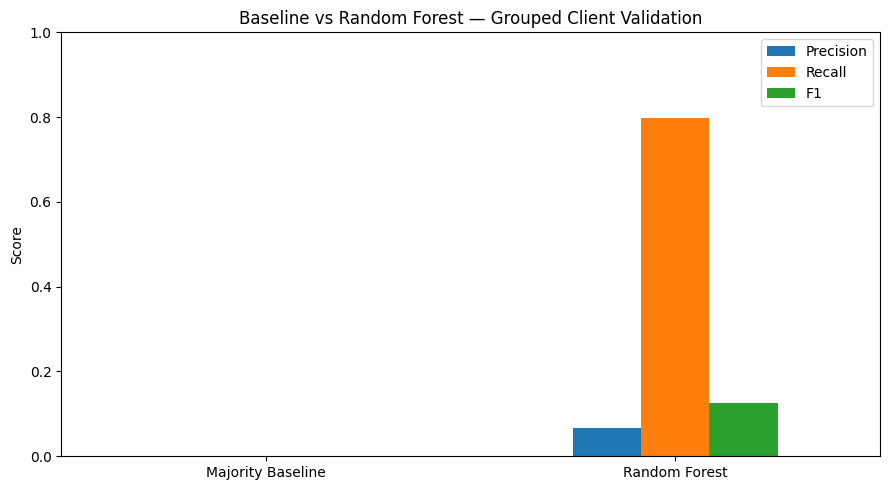

In [52]:
import matplotlib.pyplot as plt

plot_df = results.set_index("Model")[
    ["Precision", "Recall", "F1"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Baseline vs Random Forest — Grouped Client Validation"
)
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Preliminary Results

Evaluation used a client-grouped holdout split so that clients in the
test set did not appear in training. Features were calculated from the
May 2026 observation window, while the refresh-opportunity outcome was
defined using June 2026 performance.

The majority-class baseline achieved 98.13% accuracy but zero precision,
recall, and F1 for the opportunity class because it predicted no positive
opportunities.

The Random Forest achieved 79.09% accuracy, 6.78% precision, 79.87%
recall, and an F1 score of 12.55%. This indicates that the model captured
a large share of the defined future opportunities, but generated many
false positives.

These results should therefore be interpreted as a prioritization signal
for decision support rather than an automated refresh decision. Further
work is needed to improve precision and validate the scoring approach
across additional time windows.

In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score

probs = rf.predict_proba(X_test)[:, 1]

threshold_results = []

for threshold in [0.50, 0.60, 0.70, 0.80, 0.90]:
    threshold_pred = (probs >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "predicted_opportunities": threshold_pred.sum(),
        "precision": precision_score(
            y_test, threshold_pred, zero_division=0
        ),
        "recall": recall_score(
            y_test, threshold_pred, zero_division=0
        ),
        "f1": f1_score(
            y_test, threshold_pred, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(4))

,threshold,predicted_opportunities,precision,recall,f1
0,0.5,7314,0.0678,0.7987,0.1250
1,0.6,6019,0.0778,0.7536,0.1410
2,0.7,4552,0.0931,0.6828,0.1639
3,0.8,2813,0.1138,0.5153,0.1864
4,0.9,516,0.1667,0.1385,0.1513


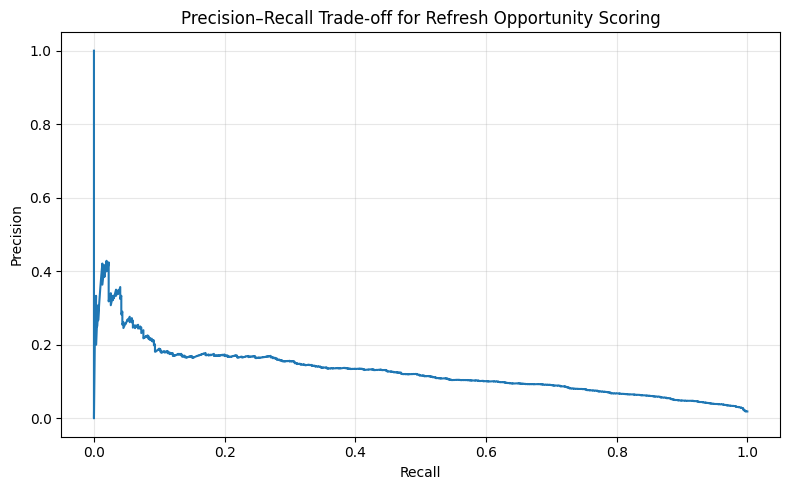

In [54]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    probs
)

plt.figure(figsize=(8, 5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Precision–Recall Trade-off for Refresh Opportunity Scoring"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
ranking_eval = pd.DataFrame({
    "actual": y_test.values,
    "score": probs
}).sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

k_results = []

for k in [50, 100, 250, 500, 1000]:
    if k <= len(ranking_eval):
        top_k = ranking_eval.head(k)

        k_results.append({
            "K": k,
            "true_opportunities": int(top_k["actual"].sum()),
            "precision_at_k": top_k["actual"].mean()
        })

precision_at_k_df = pd.DataFrame(k_results)

display(precision_at_k_df.round(4))

,K,true_opportunities,precision_at_k
0,50,16,0.320
1,100,27,0.270
2,250,54,0.216
3,500,84,0.168
4,1000,168,0.168


In [56]:
base_rate = y_test.mean()

print("Test-set opportunity base rate:",
      round(base_rate, 4))

precision_at_k_df["random_expected_precision"] = base_rate

precision_at_k_df["lift_over_random"] = (
    precision_at_k_df["precision_at_k"] / base_rate
)

display(precision_at_k_df.round(4))

Test-set opportunity base rate: 0.0187


,K,true_opportunities,precision_at_k,random_expected_precision,lift_over_random
0,50,16,0.320,0.0187,17.1089
1,100,27,0.270,0.0187,14.4357
2,250,54,0.216,0.0187,11.5485
3,500,84,0.168,0.0187,8.9822
4,1000,168,0.168,0.0187,8.9822


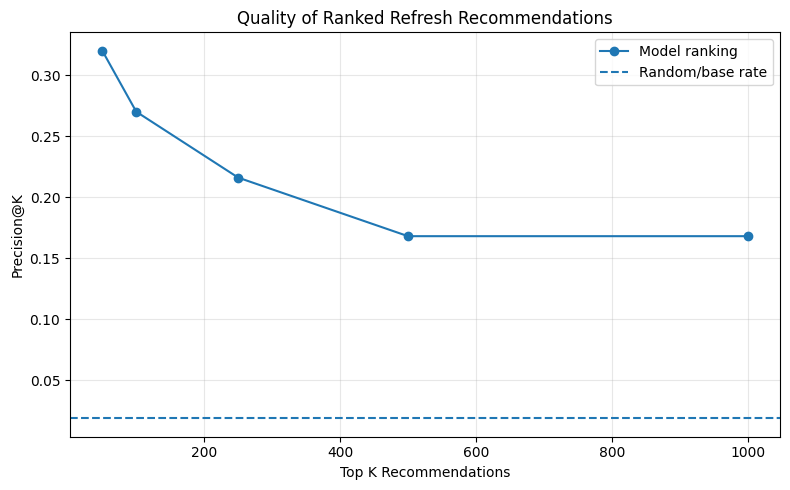

In [57]:
# Precision@K chart

plt.figure(figsize=(8, 5))

plt.plot(
    precision_at_k_df["K"],
    precision_at_k_df["precision_at_k"],
    marker="o",
    label="Model ranking"
)

plt.axhline(
    y=base_rate,
    linestyle="--",
    label="Random/base rate"
)

plt.xlabel("Top K Recommendations")
plt.ylabel("Precision@K")
plt.title("Quality of Ranked Refresh Recommendations")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

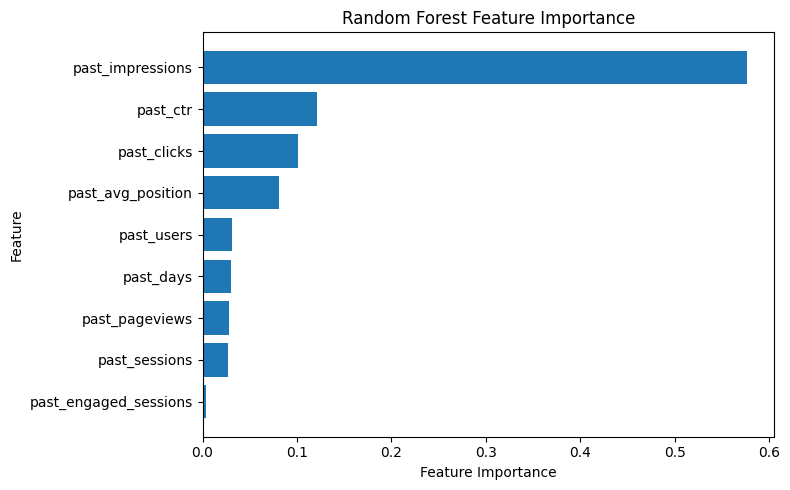

In [58]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Key Finding

The model was more useful as a ranking system than as a binary
classifier.

The opportunity class represented only about 1.87% of the grouped
test set. At the default classification threshold, the Random Forest
achieved 79.87% recall but only 6.78% precision.

However, the highest-ranked recommendations were substantially more
concentrated with future opportunities. Among the top 50 ranked
items, 32% matched the future opportunity definition, compared with
a test-set base rate of approximately 1.87%. This corresponds to
roughly 17.1× lift over the base rate.

Top-100 precision was 27%, and Top-250 precision was 21.6%.

These results suggest that the model is better interpreted as a
decision-support prioritization tool than as an automated binary
refresh classifier.

In [59]:
public_recommendations = (
    ranked_recommendations
    .head(50)
    [["priority_rank", "opportunity_score"]]
    .copy()
)

public_recommendations["recommended_action"] = (
    "Review content performance and assess refresh opportunity"
)

display(public_recommendations.head(20))

,priority_rank,opportunity_score,recommended_action
0,1,0.957477,Review content performance and assess refresh ...
1,2,0.957001,Review content performance and assess refresh ...
2,3,0.956232,Review content performance and assess refresh ...
3,4,0.955171,Review content performance and assess refresh ...
4,5,0.954577,Review content performance and assess refresh ...
5,6,0.953177,Review content performance and assess refresh ...
6,7,0.952508,Review content performance and assess refresh ...
7,8,0.952131,Review content performance and assess refresh ...
8,9,0.952101,Review content performance and assess refresh ...
9,10,0.951685,Review content performance and assess refresh ...


## Ranked Recommendations

The final output is a ranked review queue rather than an automatic
instruction to modify content.

Higher opportunity scores indicate items that the model considers
more similar to pages that met the future refresh-opportunity
definition.

Recommended workflow:

1. Review the highest-ranked items first.
2. Inspect search visibility, CTR, ranking position, and engagement.
3. Determine whether the page is outdated, poorly aligned with search
   intent, or otherwise requires editorial review.
4. Apply human judgment before making any content change.

The score should not be interpreted as evidence that refreshing a page
will cause rankings or traffic to improve.

# Refresh Opportunity Scoring:
## Prioritizing Content for Review Using Search Performance Signals

### Abstract

This study investigates whether historical search-performance signals can
help prioritize content for future review and refresh opportunities using
the FlyRank ML Internship dataset.

Performance signals from May 2026 were used as model features, while June
2026 performance was used to define future refresh opportunities.

A Random Forest model was evaluated using a client-grouped holdout split
to prevent the same clients from appearing in both training and test data.

Although binary classification precision was limited, the ranking output
was substantially more useful: the top 50 recommendations achieved 32%
Precision@50 compared with a test-set opportunity base rate of about
1.87%, representing approximately 17.1x lift over the base rate.

The results suggest that historical search-performance signals can provide
a useful decision-support ranking for editorial review, while further
validation is required before the scores should be used for automated
content decisions.

## 1. Introduction and Problem Statement

Content teams may manage large numbers of pages, making it difficult to
decide which pages should be reviewed first.

This project explores whether historical search and engagement signals can
be used to create a ranked queue of potential content refresh opportunities.

The research question is:

**Which content pages should be prioritized for review or refresh based on
observed search-performance signals?**

The goal is not to prove that refreshing content causes ranking or traffic
improvements. Instead, the model is designed as a decision-support tool
that helps analysts prioritize pages for human review.

## 2. Data

This project uses the FlyRank ML Internship warehouse dataset.

The analysis uses daily content-performance data containing pseudonymized
client and content identifiers together with Google Search Console and GA4
performance signals.

The June 2026 sample contained:

- 11,694,072 daily records
- 65 clients
- 409,205 content items
- 216,194,872 impressions
- 1,209,117 clicks
- 4,861,097 pageviews
- 2,759,763 sessions

The modeling design uses May 2026 as the historical feature window and
June 2026 as the future outcome window.

No client names, domains, URLs, private queries, credentials, or raw
warehouse exports are included in the public output.

## 3. Methodology

Content-level historical features were aggregated from the May 2026 daily
performance data.

Features included:

- impressions
- clicks
- click-through rate (CTR)
- average search position
- pageviews
- sessions
- users
- engaged sessions
- number of observed days

A future refresh-opportunity label was defined from June 2026 performance.
Eligible content needed positive search impressions and a valid average
position.

An opportunity was operationally defined as content with relatively high
search visibility but relatively weak CTR. Thresholds were calculated from
the June eligible-content distribution rather than treated as universal
SEO rules.

A Random Forest classifier was trained using only May features.

Validation used a grouped holdout split based on pseudonymized client ID.
There was zero client overlap between the training and test sets.

A leakage audit confirmed that no June future-outcome variables were used
as model predictors.

## 4. Results

The majority-class baseline achieved:

- Accuracy: 98.13%
- Precision: 0.00%
- Recall: 0.00%
- F1: 0.00%

Despite its high accuracy, the baseline identified no positive
opportunities, demonstrating why accuracy alone was misleading for this
imbalanced task.

The Random Forest achieved:

- Accuracy: 79.09%
- Precision: 6.78%
- Recall: 79.87%
- F1: 12.55%

The opportunity class represented approximately 1.87% of the grouped
test set.

Ranking performance was stronger than binary classification performance:

- Precision@50: 32.0%
- Precision@100: 27.0%
- Precision@250: 21.6%
- Precision@500: 16.8%
- Precision@1000: 16.8%

The top 50 recommendations produced approximately 17.1x lift over the
test-set opportunity base rate.

Feature-importance analysis showed that historical impressions were the
largest contributor to the Random Forest, followed by historical CTR,
clicks, and average position.

## 5. Limitations and Honest Framing

This study has several important limitations.

First, the refresh-opportunity label is an operational definition based on
observed performance signals. It is not ground-truth evidence that a page
requires a refresh.

Second, the Random Forest generated many false positives. Its low binary
precision means that predictions should not be interpreted as automatic
refresh decisions.

Third, the primary experiment uses May 2026 to predict opportunities
defined from June 2026. Additional rolling or future time windows would
provide stronger evidence of temporal stability.

Fourth, feature importance describes how the fitted Random Forest used the
available variables; it does not establish causal relationships.

Finally, this analysis does not demonstrate that refreshing content causes
higher Google rankings, traffic, CTR, or engagement.

## 6. Ranked Recommendations

The model is best used as a prioritization system rather than an automated
binary classifier.

A practical workflow is:

1. Rank eligible content by predicted opportunity score.
2. Review the highest-ranked pages first.
3. Inspect search visibility, CTR, ranking position, and engagement signals.
4. Assess whether each page is outdated, poorly aligned with search intent,
   or otherwise requires editorial attention.
5. Apply human judgment before making content changes.

The highest-ranked group showed substantially greater concentration of the
defined future opportunities than random selection.

Therefore, the score should be treated as a decision-support signal for
prioritizing analyst attention.

## 7. Reproducibility

The complete analysis notebook is included in the project repository:

`work/notebooks/capstone_refresh_opportunity.ipynb`

The notebook documents:

- data access and aggregation
- feature engineering
- opportunity-label construction
- client-grouped validation
- baseline comparison
- Random Forest modeling
- leakage checks
- threshold sensitivity
- Precision@K evaluation
- feature importance
- ranked recommendations

Raw warehouse data and identifying information are not redistributed.

## 8. Acknowledgments and Data Credit

Built on the FlyRank ML Internship dataset.

Data and internship resources provided by FlyRank:

https://flyrank.ai